In [1]:
# Final pipeline running on grand arrays created for each experiment
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
import pandas as pd
from scipy.ndimage import uniform_filter1d
from scipy.ndimage import gaussian_filter1d
from IPython.display import HTML
from cleaning_pipeline_functions import *
from scipy.signal import savgol_filter

### Loading data

In [2]:
# loading data - the grand array
file_path = Path('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/data/grand_array.npy')
parent_dir = file_path.resolve().parent
data = np.load(file_path)
no_of_fishes = data.shape[0]
no_of_frames = data.shape[1]
data[np.isinf(data)] = np.nan
# data.shape

### Visualising the speeds - speedy trail


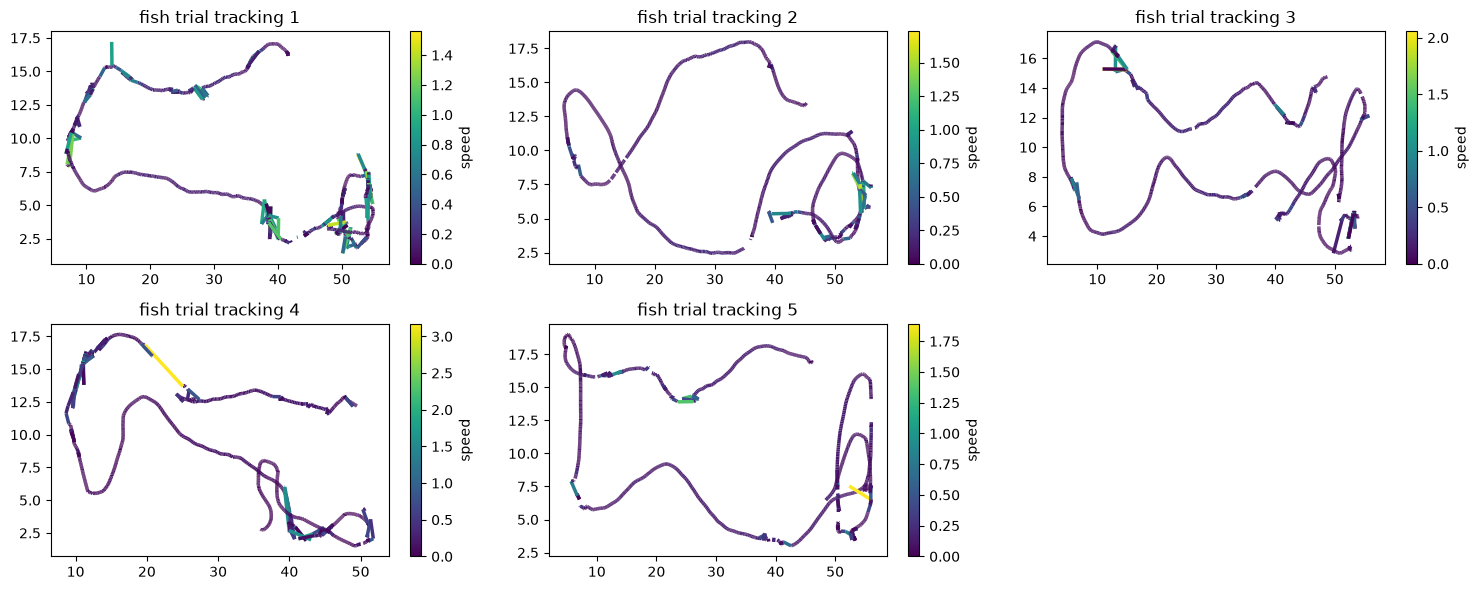

In [3]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    current_axis = flat_axes[i]
    time_steps = no_of_frames
    fish_x = data[i, :, 0]
    fish_y = data[i, :, 1]
    # fish_speeds = speed[i, :]
    speedy_trail(fish_x, fish_y, ax=current_axis, label=f"Fish {i+1}")
    current_axis.set_title(f"fish trial tracking {i+1}")

plt.tight_layout()
plt.show() 

### Visualising corrections


0.15
Fraction of track retained for fish 1: 0.766
0.15
Fraction of track retained for fish 2: 0.881
0.15
Fraction of track retained for fish 3: 0.894
0.15
Fraction of track retained for fish 4: 0.837
0.15
Fraction of track retained for fish 5: 0.866


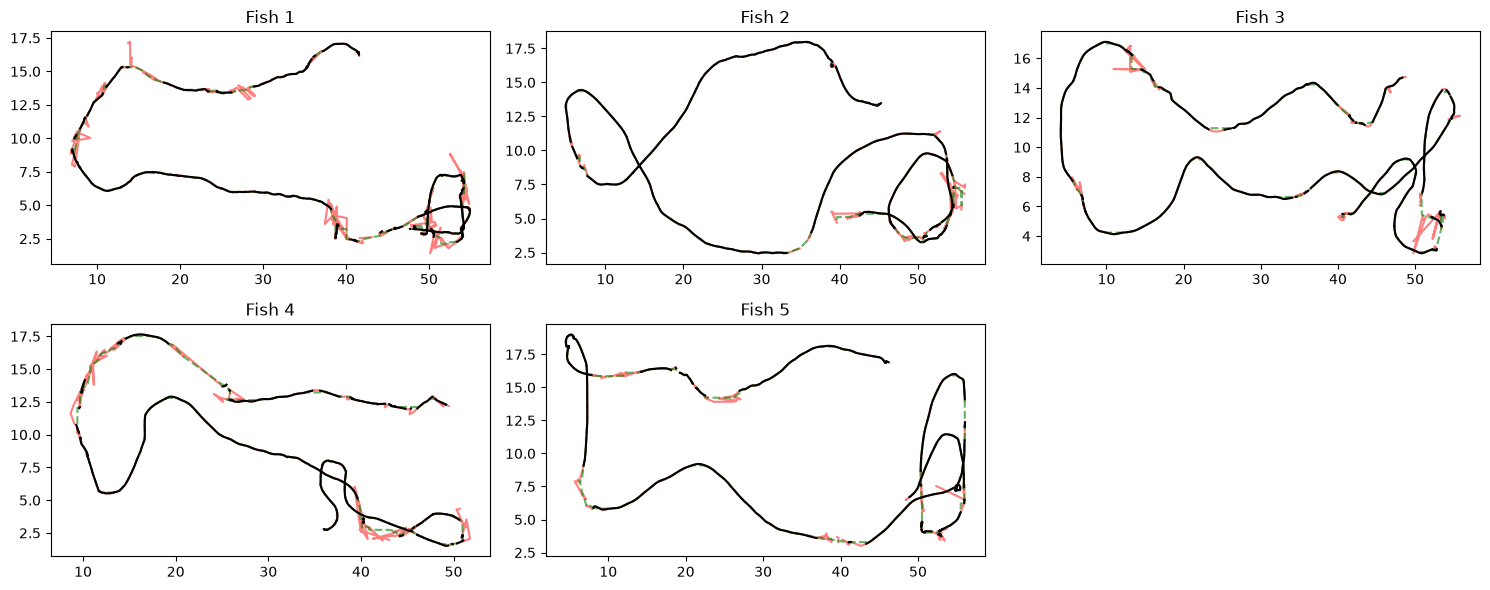

In [4]:
# Blanketting alone suffices 
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

data_blanket = data.copy()

for i in range(no_of_fishes):
    x = data[i, :, 0]
    y = data[i, :, 1]
    
    x_med_corrected, y_med_corrected, x_med_smooth, y_med_smooth, frac = blanket(x, y,method="median", r=0.15)
    data_blanket[i, :, 0] = x_med_corrected
    data_blanket[i, :, 1] = y_med_corrected
    
    flat_axes[i].plot(x, y, 'r', alpha=0.5)
    flat_axes[i].plot(x_med_smooth, y_med_smooth, 'g--', alpha=0.6)
    flat_axes[i].plot(x_med_corrected, y_med_corrected, 'k')

    # flat_axes[i].text(0.73, 0.8, f"frac_retained=\n{round(frac,3)}", transform=flat_axes[i].transAxes)
    flat_axes[i].set_title(f"Fish {i+1}")
    print(f"Fraction of track retained for fish {i+1}:", round(frac,3))

plt.tight_layout()
plt.show()

### Visualising interpolated tracks


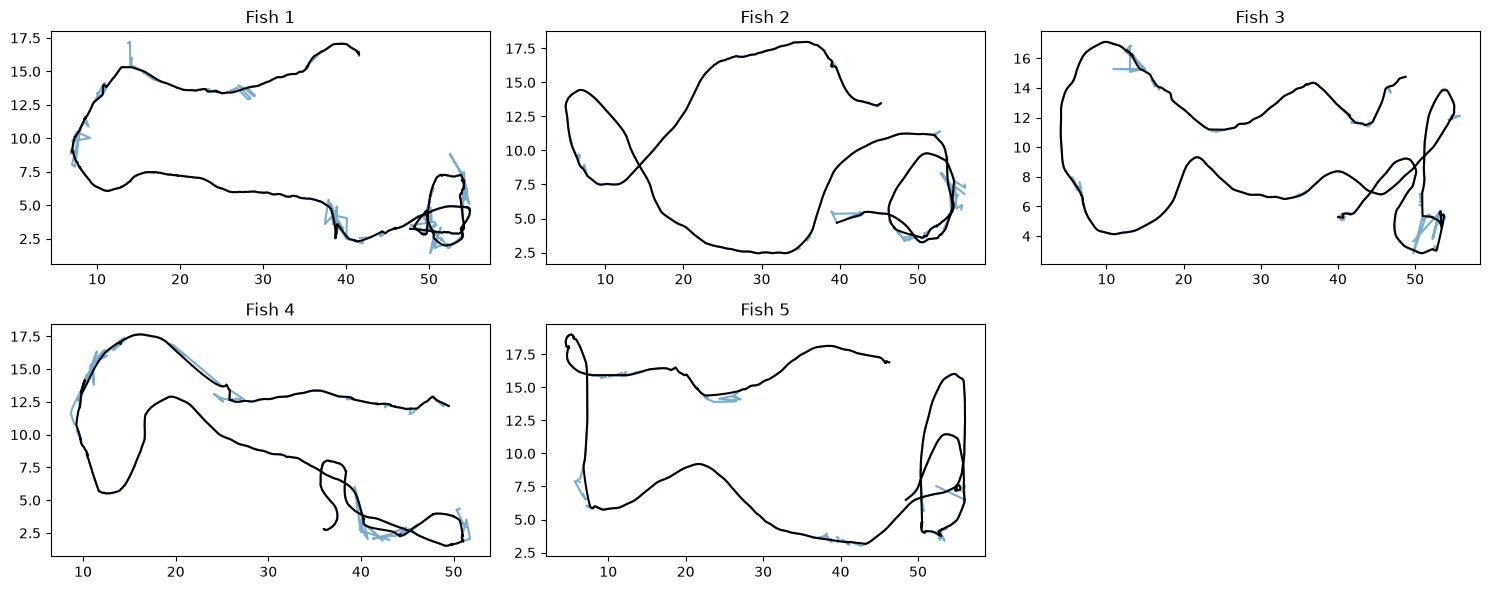

In [5]:
# interpolating
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

data_final = np.zeros(data.shape)

for i in range(no_of_fishes):
    x = data[i, :, 0]
    y = data[i, :, 1]
    
    x_blanket_0 = data_blanket[i, :, 0]
    y_blanket_0 = data_blanket[i, :, 1]

    x_interp = pd.Series(x_blanket_0).interpolate(method='pchip').to_numpy()
    y_interp = pd.Series(y_blanket_0).interpolate(method='pchip').to_numpy()

    data_final[i, :, 0] = x_interp
    data_final[i, :, 1] = y_interp

    flat_axes[i].plot(x, y, alpha=0.6)
    flat_axes[i].plot(x_interp, y_interp, color='black')
    flat_axes[i].set_title(f"Fish {i+1}")
plt.tight_layout()
plt.show()

/home/hck03/Documents/MS_thesis/coding/codes/relevant/cleaning_pipeline_functions.py:114: RuntimeWarning: invalid value encountered in scalar divide
  cos_theta = dot_prod/denom


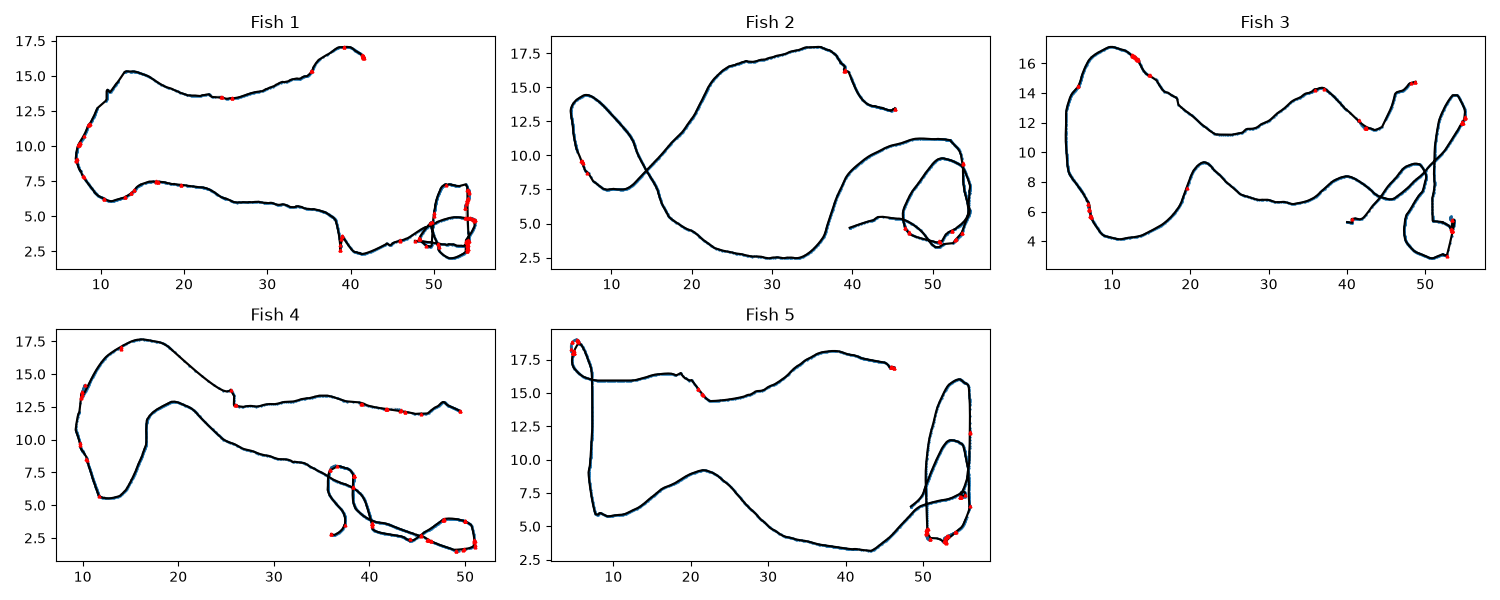

In [13]:
# Removing angle spikes
# %matplotlib widget
fig, ax = plt.subplots(2,3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

data_final_clean = np.zeros(data.shape)

positions = data_final.copy()
vectors = np.diff(positions, axis=1)

for i in range(no_of_fishes):
    x_temp = data_final[i, :, 0].copy()
    y_temp = data_final[i, :, 1].copy()
    vec_temp = np.squeeze(vectors[i,:,:]).copy()
    # flat_axes[i].plot(x_temp, y_temp, alpha=1)
    angle_spikes_temp = detect_angle_spikes(vec_temp, angle_threshold=0.0)
    angle_spikes_temp[0], angle_spikes_temp[-1] = True, True
    x_temp_clean, y_temp_clean = clean_angle_spikes(x_temp, y_temp, angle_spikes_temp, vec_temp)

    x_interp_c = pd.Series(x_temp_clean).interpolate(method='pchip').to_numpy()
    y_interp_c = pd.Series(y_temp_clean).interpolate(method='pchip').to_numpy()

    data_final_clean[i, :, 0] = x_interp_c
    data_final_clean[i, :, 1] = y_interp_c
    flat_axes[i].plot(x_temp, y_temp, color='k', alpha=0.2)
    flat_axes[i].scatter(x_temp, y_temp, alpha=1, s=0.5)
    flat_axes[i].plot(x_interp_c, y_interp_c, 'k')
    for j in angle_spikes_temp:
        flat_axes[i].plot(x_temp[j], y_temp[j], color='red', marker='^', markersize=2)

    flat_axes[i].set_title(f"Fish {i+1}")
plt.tight_layout()
plt.show()

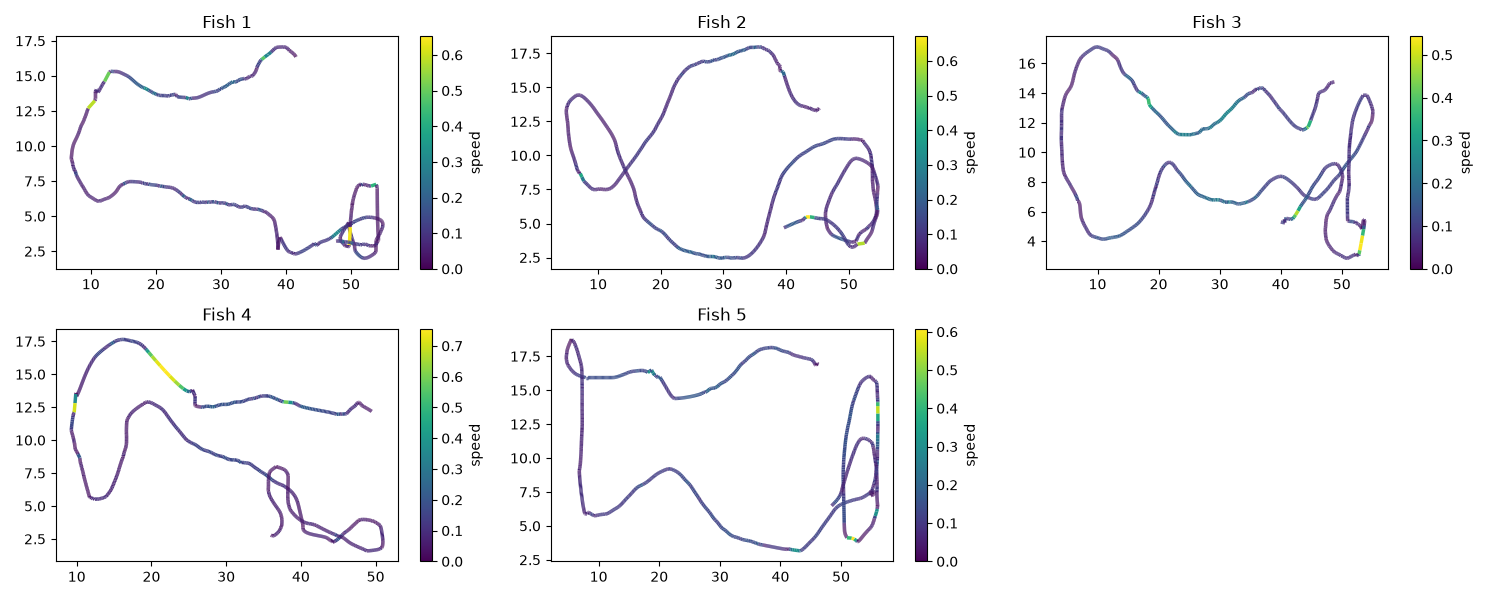

In [12]:
### Run if needed - speedy trail of the corrected data
# interpolated plots speedy trails
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    x_intp_speed = data_final_clean[i, :, 0]
    y_intp_speed = data_final_clean[i, :, 1]

    speedy_trail(x_intp_speed, y_intp_speed, flat_axes[i])
    # flat_axes[i].plot(x_interp, y_interp, color='black')
    flat_axes[i].set_title(f"Fish {i+1}")
plt.tight_layout()
plt.show()

### Saving data


In [15]:
# change the file name if needed
file_name = parent_dir / "clean_tracks_1.npy"
np.save(file_name, data_final_clean)

### All trajectories plot


In [ ]:
# grand plot 

length = 10
# aspect_x, aspect_y = 1380, 596
fig = plt.figure(figsize=(length,(length/(50/20))))
ax = fig.add_axes([0, 0, 1, 1])
# ax.axis('off')
xmin, xmax = 0, 50
ymin, ymax = 0, 50/(50/20)


ax.set_xticks([])
ax.set_yticks([])
mid_way = (np.nanmin(data_final[:,:,0]) + np.nanmax(data_final[:,:,0]))/2
ax.axvline(x=22)
ax.axvline(x=30.5)


for i in range(no_of_fishes):
    track = data_final[i, :, :]
    track_x = track[:,0]
    track_y = track[:,1]
    
    # ax.invert_xaxis()
    ax.plot(track_x, track_y, label = f"fish {i+1}")
ax.invert_yaxis()
# img = plt.imread('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/average_Clip0070_1C_4N_E3_8.png')
# ax.imshow(img, extent=[xmin, xmax, ymin, ymax], aspect='auto', zorder=0)
ax.legend(loc = "upper left", framealpha = 0.5)

### If you want to create a video file of the tracks run this!

In [ ]:
# to get a video file of single track
fish_id = 2
file_name = parent_dir / f"single_track_{fish_id}"
animate_trajectory(data_final[fish_id, :, 0], data_final[fish_id, :, 1], filename=file_name)

In [ ]:
# to get a video file of all tracks
colors = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']
file_name = parent_dir / f"all_fish_vid"
animate_trajectory_all(data_final, filename=file_name, colors=colors)